In [24]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sbn

In [2]:
Ideal_Condition = pd.read_csv("Ideal.csv.csv")

In [3]:
Minor_Fault = pd.read_csv("One_band.csv.csv")

In [4]:
Major_Fault = pd.read_csv("Two_band.csv.csv")

In [5]:
Ideal_Condition = Ideal_Condition.drop(columns=["time", "Unnamed: 4"])

In [6]:
Minor_Fault = Minor_Fault.drop(columns=["time", "Unnamed: 4"])
Major_Fault = Major_Fault.drop(columns=["time", "Unnamed: 4"])

In [7]:
Ideal_Condition["Output"] = 0
Minor_Fault["Output"] = 1
Major_Fault["Output"] = 2

In [8]:
Ultimate_Data = pd.concat([Ideal_Condition, Minor_Fault, Major_Fault], ignore_index= True)

In [9]:
Ultimate_Data

,MPU6050_Data.AX,MPU6050_Data.AY,MPU6050_Data.AZ,Output
0,0.010986,0.093018,0.986328,0
1,0.010986,0.093018,0.986328,0
2,0.024170,-0.184570,0.954346,0
3,0.024170,-0.184570,0.954346,0
4,0.024170,-0.184570,0.954346,0
...,...,...,...,...
97249,-0.113037,0.891846,1.905762,2
97250,-0.113037,0.891846,1.905762,2
97251,-0.113037,0.891846,1.905762,2
97252,-0.105225,0.948242,0.916748,2


In [10]:
Ultimate_Data = shuffle(Ultimate_Data).reset_index(drop=True)

In [11]:
Ultimate_Data

,MPU6050_Data.AX,MPU6050_Data.AY,MPU6050_Data.AZ,Output
0,-0.031006,0.482178,1.316162,1
1,0.036621,0.195068,0.941895,0
2,0.023438,0.127441,0.981201,1
3,0.032959,-0.341553,1.045898,1
4,0.036377,0.136963,0.977051,0
...,...,...,...,...
97249,0.165039,-0.631836,0.504395,2
97250,-0.153320,0.260498,1.038086,2
97251,0.170410,-1.257324,0.730957,2
97252,-0.135498,0.023682,1.011719,2


In [12]:
x = Ultimate_Data[['MPU6050_Data.AX', 'MPU6050_Data.AY', 'MPU6050_Data.AZ']].values
y = Ultimate_Data['Output'].values

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [14]:
print(y_train.shape)
print(y_train.dtype)
print(y_train[:10])

print(np.unique(y_train))

(68077,)
int64
[2 0 2 1 2 2 2 0 1 1]
[0 1 2]


In [15]:
model = tf.keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])


model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


model.fit (x_train, y_train, epochs=50)

Epoch 1/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6734 - loss: 0.7436
Epoch 2/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8203 - loss: 0.4815
Epoch 3/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8779 - loss: 0.3816
Epoch 4/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8918 - loss: 0.3107
Epoch 5/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9117 - loss: 0.2650
Epoch 6/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9230 - loss: 0.2437
Epoch 7/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9279 - loss: 0.2283
Epoch 8/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9372 - loss: 0.1948
Epoch 9/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9450 - loss: 0.1729
Epoch 10/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9489 - loss: 0.1620
Epoch 11/50
2128/2128 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9517 - loss: 0.1495
Epoch 12/50
2128/2128 ━━━━━━━━

In [16]:
predicted = model(x_test)
predicted = predicted.numpy()
predicted_class = predicted.argmax(axis=1)

In [17]:
predicted_class

array([1, 1, 1, ..., 2, 2, 0], shape=(29177,))

In [18]:
y_test

array([1, 1, 1, ..., 2, 2, 0], shape=(29177,))

In [19]:
cm = confusion_matrix(y_test, predicted_class)

print(cm)

[[9130   97   12]
 [ 385 9454   39]
 [  83  120 9857]]


In [20]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predicted_class)
print("Accuracy:", accuracy)

Accuracy: 0.9747746512664085


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_class))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9239
           1       0.98      0.96      0.97      9878
           2       0.99      0.98      0.99     10060

    accuracy                           0.97     29177
   macro avg       0.97      0.98      0.97     29177
weighted avg       0.98      0.97      0.97     29177



<Axes: >

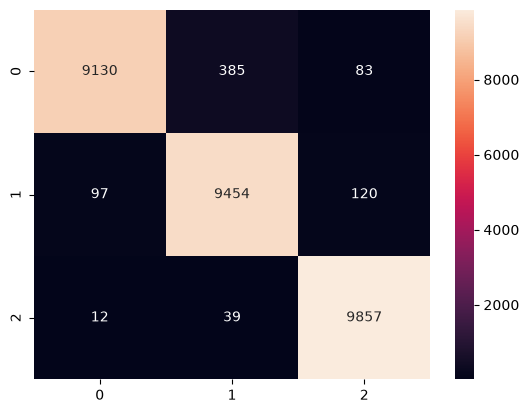

In [25]:
cm=tf.math.confusion_matrix(predicted_class, y_test)
sbn.heatmap(cm, annot=True, fmt='d')

In [26]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
lite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmp2xrmijgx\assets


INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmp2xrmijgx\assets


Saved artifact at 'C:\Users\rajmo\AppData\Local\Temp\tmp2xrmijgx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1761950117584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1761950110864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1762957994768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1762957997456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1762957995344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1762957994192: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [27]:
with open('Lite_model.tflite', 'wb') as f:
    f.write(lite_model)

In [30]:
def generate_c_header(bytes_data, var_name):
    hex_array = [f'0x{b:02x}' for b in bytes_data]
    c_str = f'const unsigned char {var_name}[] __attribute__((aligned(4))) = {{\n  '
    c_str += ',\n  '.join([', '.join(hex_array[i:i+12]) for i in range(0, len(hex_array), 12)])
    c_str += f'\n}};\n\nconst unsigned int {var_name}_len = {len(bytes_data)};'
    return c_str

with open ('Converted_model.h', 'w') as f:
    f.write(generate_c_header(lite_model, "Converted_model"))

In [1]:
Test_Fault = pd.read_csv("test_2.csv")

NameError: name 'pd' is not defined